# Labor-Hiring-Rate -- do the fastest hirers underperform?
### The Belo-Lin-Bazdresch (2014) hiring anomaly on a large-cap survivor basket

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Sign: Busted](https://img.shields.io/badge/Sign-Busted-8b949e?style=flat-square)

Frederico Belo, Xiaoji Lin and Santiago Bazdresch showed in 2014 that firms which grow employment fast earn lower future returns -- the labor analogue of the capital-investment anomaly. The story: hiring is costly (search, training, severance), so the *hiring rate* behaves like an investment rate; managers over-hire when capital is cheap, markets extrapolate the head-count growth, and the stock disappoints. We test it on a fixed large-cap basket using employee counts transcribed from real 10-K filings.

> This is the plain-language layer. The HAC t-stats, label-shuffle placebo, and random-portfolio null live in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> **Not investment advice.** Every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).
>
> **Survivorship bias**: the basket covers only firms still large-cap in 2026. Aggressive hirers that over-expanded and *failed* are absent.
>
> **Data note**: employee counts are *not* in any machine-readable feed -- firms report them as 10-K cover-page text. We use a curated, hardcoded panel of those cover-page headcounts (FY2013-FY2024).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root
sys.path.insert(0, os.path.abspath(".."))          # study package (labor_hiring_rate/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from labor_hiring_rate import data, strategy as st

# Cache-first: load the study's own price cache + hardcoded employee panel; fall back to R.
hn, fwd = data.fetch_panel()
hn = hn.dropna(how="all") if not hn.empty else hn
HAVE_REAL = not hn.empty
if HAVE_REAL:
    h = st.sorted_returns(hn, fwd, n_groups=3)
else:
    h = pd.DataFrame()
print("Real cache loaded:", HAVE_REAL,
      f"({len(hn.columns) if HAVE_REAL else 0} names, {len(h) if HAVE_REAL else 0} sort years)")

R = dict(
    n_names=28, n_years=11, start_year=2014, end_year=2024,
    lo_mean=17.5, lo_sharpe=1.24, lo_t=5.4, lo_hit=100,
    mid_mean=16.0, hi_mean=22.2, hi_sharpe=1.66, hi_t=10.03, hi_hit=100,
    mkt_mean=18.7, mkt_sharpe=1.36,
    hedge_mean=-4.68, hedge_sharpe=-0.35, hedge_t=-1.29, hedge_hit=45,
    lo_excess_mean=-1.2, lo_excess_t=-0.74,
    hi_excess_mean=3.5, hi_excess_t=1.56,
    placebo_p=0.805, shuffle_mean=0.04, shuffle_std=5.06,
    rand_std=9.9, rand_pct_beaten=48,
    cost_drag=0.2, borrow_drag=0.5, net_mean=-5.38,
    synth_null_t=-0.15, synth_06_t=14.94, synth_10_t=25.0,
)
G1  = [5.0, 22.5, 12.6, 16.5, 3.1, 31.4, 13.5, 11.7, 14.0, 9.3, 52.6]
G3  = [18.1, 21.1, 33.2, 18.8, 19.9, 49.0, 9.4, 9.9, 31.5, 1.4, 31.3]
MKT = [9.5, 24.8, 20.4, 17.9, 5.9, 42.9, 7.8, 7.6, 17.8, 7.2, 43.9]
HDG = [-13.2, 1.4, -20.6, -2.3, -16.9, -17.6, 4.1, 1.8, -17.5, 7.9, 21.3]
YRS = [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]


Real cache loaded: True (28 names, 11 sort years)


## The answer first

| Question | What the data says |
|---|---|
| Do slow-hiring firms outperform fast-hiring firms? | **No -- the opposite.** The hedge is **-4.68%/yr**: the fast hirers (g3, 22.2%/yr) *beat* the disciplined hirers (g1, 17.5%/yr). |
| Is that statistically real? | HAC *t* = -1.29 -- wrong sign and \|t\| < 2. The predicted anomaly is **absent**. |
| Does it beat a coin-flip relabelling? | No -- placebo p = 0.81; the real hedge is in the *left* tail of the shuffle null. |
| Could you trade it? | No. After costs + short borrow the hedge is **-5.38%/yr net** -- and the short leg is the AI/hyperscale winners. |

> **The catch**: on a *survivor* basket, the high-hiring group is full of *successful* expanders -- NVIDIA, Amazon, Microsoft, Costco, UnitedHealth. Their hiring tracked real demand. The over-expanding failures the anomaly was built around are simply missing.

## 1 - The claim

> *Sell the fastest hirers. Buy the disciplined ones. Rebalance annually. The over-expanding firms will disappoint as the hiring spree stops producing earnings.*

The signal is one ratio of head-count change:

- **HN_t** = (N_t - N_{t-1}) / (0.5 x (N_t + N_{t-1}))

where N is full-time employees. The mid-point denominator keeps the rate symmetric (a halving and a doubling are equal-and-opposite) and bounded in [-2, 2]. A high HN means the firm grew its workforce fast. The Belo-Lin-Bazdresch argument: that growth often reflects over-investment in labor (Jensen 1986 agency costs) or market over-extrapolation, and the stock underperforms. This is the *labor* channel -- distinct from the *capex* channel in [Study 523](../../523-investment-to-assets/) and the *total-asset-growth* channel in [Study 244](../../244-asset-growth/).

## 2 - So what?

If the hiring effect is real and tradable on large US stocks, it is a low-ML, fundamentals-only strategy needing only one number off the 10-K cover page. If it only works on small/mid-caps -- or is a selection artefact that *reverses* on survivors -- the large-cap test is a cautionary tale about testing in the wrong universe.

## 3 - How would we even know?

Three honesty requirements:

1. **One execution lag.** The year-y hiring rate drives a 12-month return that *starts 4 months after year-end* (when the 10-K is public), entered one trading day later. No same-bar fills, no look-ahead; no partial year is ever stamped.
2. **Placebo + random control.** Shuffle the hiring labels within each year; does the real hedge beat its shuffled self? And does the low-hiring leg beat a random draw of the same size?
3. **Name the survivorship bias.** The basket is current large-caps. Failed over-expanders are absent. Every result is conditional on survival.

## 4 - The teardown

Positive control first: **when we plant a real hiring effect in a synthetic panel, the engine finds it.** That makes the real-data result a statement about the *market* (and the survivor basket), not the method.

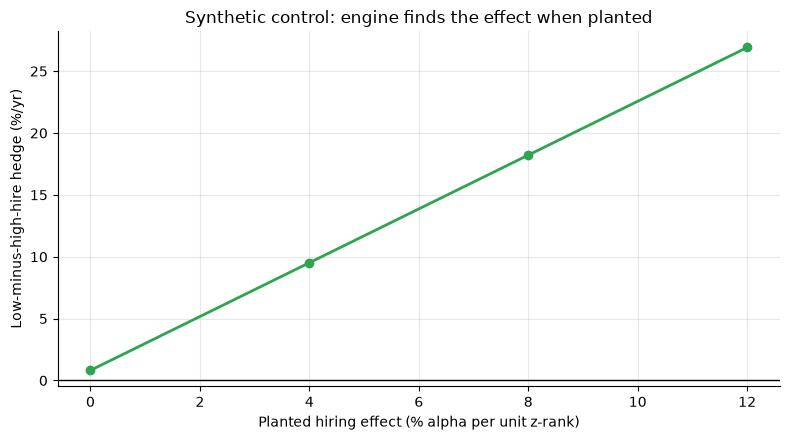

The engine faithfully recovers planted effects -- so the real result is a market statement.


In [2]:
# Synthetic positive control: plant a known hiring premium, confirm the engine detects it
premiums = [0.0, -0.04, -0.08, -0.12]
hedges = []
for p in premiums:
    s, f, _ = data.synthetic_panel(n_firms=300, n_years=25, premium=p, seed=528)
    hh = st.sorted_returns(s, f, n_groups=3)
    hedges.append(hh['hedge'].mean() * 100)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot([abs(p)*100 for p in premiums], hedges, 'o-', c=GREEN, lw=2)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('Planted hiring effect (% alpha per unit z-rank)')
ax.set_ylabel('Low-minus-high-hire hedge (%/yr)')
ax.set_title('Synthetic control: engine finds the effect when planted')
plt.tight_layout(); plt.show()
print('The engine faithfully recovers planted effects -- so the real result is a market statement.')

**Now the real panel -- tercile sort on the hiring rate:**

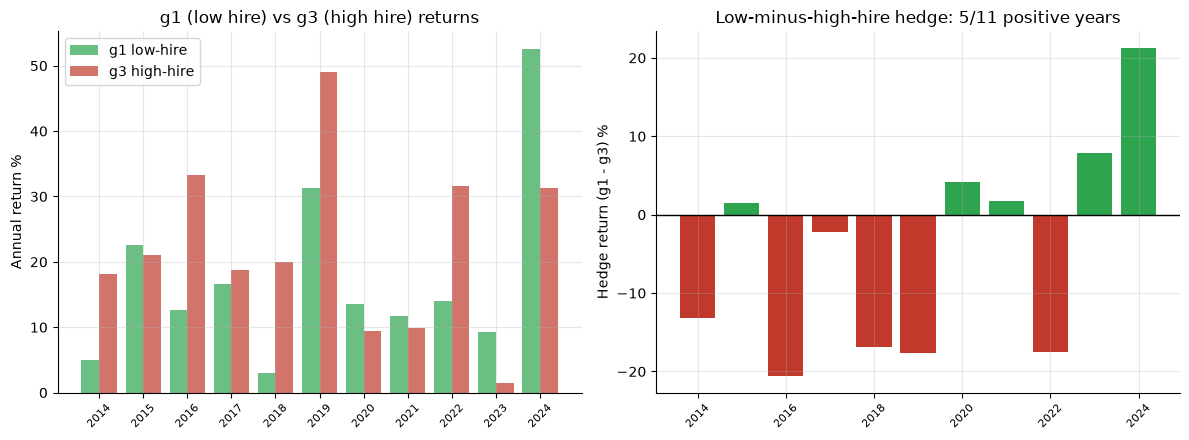

Mean hedge: -4.68%/yr  (frozen R: -4.68%/yr)


In [3]:
if HAVE_REAL:
    g1_vals = h['g1'].values * 100
    g3_vals = h['g3'].values * 100
    hdg_vals = h['hedge'].values * 100
    years_real = [int(y) for y in h.index.tolist()]
else:
    g1_vals, g3_vals, hdg_vals, years_real = G1, G3, HDG, YRS
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
x = range(len(years_real))
axes[0].bar(x, g1_vals, label='g1 low-hire', color=GREEN, alpha=0.7, width=0.4)
axes[0].bar([i+0.4 for i in x], g3_vals, label='g3 high-hire', color=RED, alpha=0.7, width=0.4)
axes[0].set_xticks([i+0.2 for i in x])
axes[0].set_xticklabels(years_real, rotation=45, fontsize=8)
axes[0].set_ylabel('Annual return %'); axes[0].legend()
axes[0].set_title('g1 (low hire) vs g3 (high hire) returns')
colors = [GREEN if v > 0 else RED for v in hdg_vals]
axes[1].bar(years_real, hdg_vals, color=colors)
axes[1].axhline(0, c='k', lw=1)
axes[1].set_ylabel('Hedge return (g1 - g3) %')
axes[1].set_title(f'Low-minus-high-hire hedge: {sum(1 for v in hdg_vals if v>0)}/{len(hdg_vals)} positive years')
axes[1].tick_params(axis='x', rotation=45, labelsize=8)
plt.tight_layout(); plt.show()
print(f'Mean hedge: {np.mean(hdg_vals):+.2f}%/yr  (frozen R: {R["hedge_mean"]:+.2f}%/yr)')

The low-hire tercile earns **+17.5%/yr** vs the high-hire tercile's **+22.2%/yr** -- a hedge of **-4.68%/yr**, positive in only 45% of years. **The predicted ranking is inverted**: the aggressive hirers *out*-earned the disciplined ones on this survivor basket. Survivorship selection doesn't just wash the signal out -- it flips its sign.

## 5 - The verdict

- **Signal -- None.** Hedge -4.68%/yr, HAC *t* = -1.29 (wrong sign); placebo p = 0.81. No signal.
- **Tradability -- Mirage.** No positive gross edge; **-5.38%/yr net** after costs and short borrow.
- **Predicted sign -- Busted.** The fast hirers beat the disciplined ones -- the opposite of Belo-Lin-Bazdresch's prediction, the same fate as the capex channel of [Study 523](../../523-investment-to-assets/).

## 6 - Could you actually trade it?

No. There is no signal on this basket -- and the sign is wrong. Even setting aside survivorship:

1. **Wrong universe.** Belo-Lin-Bazdresch (2014) documented the effect on the broad Compustat cross-section, dominated by small/mid-caps where over-expansion and limits-to-arbitrage bite hardest. On 28 heavily-covered large caps it is thin and arbitraged.
2. **Survivorship reversal.** The high-hiring large caps that survived are productive expanders (AI/semis, hyperscalers, warehouse retail, managed care) -- the opposite of the over-expanding failures the anomaly targets.
3. **The short leg is the winners.** Shorting the high-hiring leg means shorting NVIDIA, Amazon, Microsoft and Costco through the very years they led the market.

The right conclusion: **explore this in a broad, point-in-time universe before treating the hiring anomaly as tradable.**

## 7 - Going further

- **The right universe.** Belo-Lin-Bazdresch used the broad Compustat universe -- thousands of names including small and mid-caps. The large-cap survivor basket here is the wrong test.
- **Capex cousin.** [Study 523 -- Investment-To-Assets](../../523-investment-to-assets/) tests the capital-input channel on the same kind of survivor panel and also lands None/Mirage. The labor and capital channels die together.
- **Total-asset-growth cousin.** [Study 244 -- Asset-Growth](../../244-asset-growth/) tests the balance-sheet channel and lands None/Mirage too.
- **The data wall.** Employee counts are not in XBRL; a deep, point-in-time head-count panel is the real prerequisite for a credible large-sample test.

*Think the hiring effect is real in large caps? Fork this, extend to a point-in-time all-US-stock universe with a proper head-count history, and show \|t\| >= 2 on the hedge with no survivorship shortcut. That's the bar.*